# Time Series Training

## Reducing Granularity

In [1]:
import pandas as pd

# 1. load original data
df = pd.read_csv("smart_sensors.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['humid'] = pd.to_numeric(df['humid'], errors='coerce')
df = df.sort_values("result_time")

# 2. mobile average in order to reduce granularity
df_resampled = df.set_index('result_time').resample('1min').mean().interpolate()

# 3. save new granularity dataset
df_resampled.to_csv("smart_sensors_smoothed.csv")

/var/folders/k5/2x805v8s36zft24jm8_zy2980000gn/T/ipykernel_5541/1808107311.py:4: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("smart_sensors.csv")


## Data Visualization & Exploration Analysis

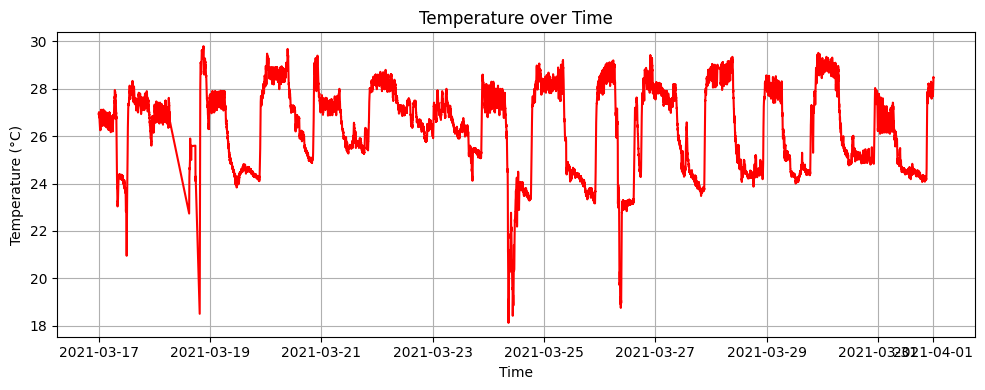

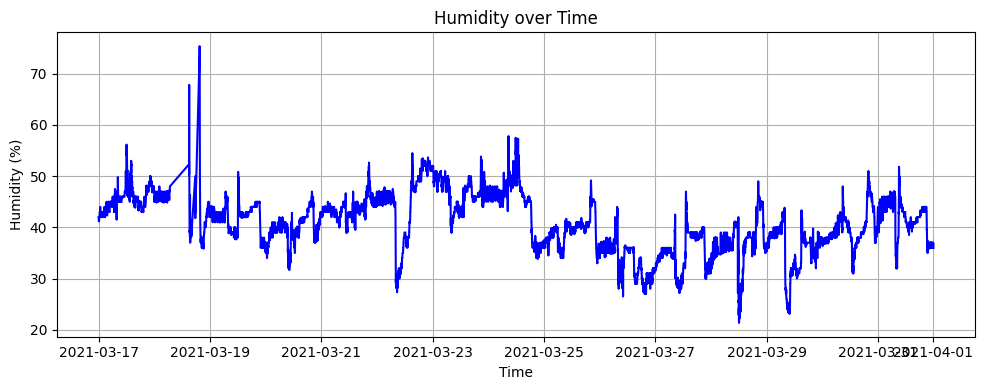

ADF Statistic: -6.593527019989312
p-value: 7.0174796664726624e-09
ADF Statistic: -6.040696460882807
p-value: 1.3482226691105786e-07


<Figure size 800x400 with 0 Axes>

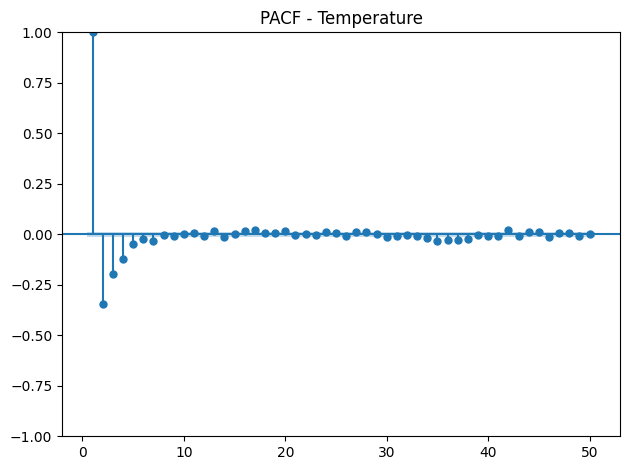

<Figure size 800x400 with 0 Axes>

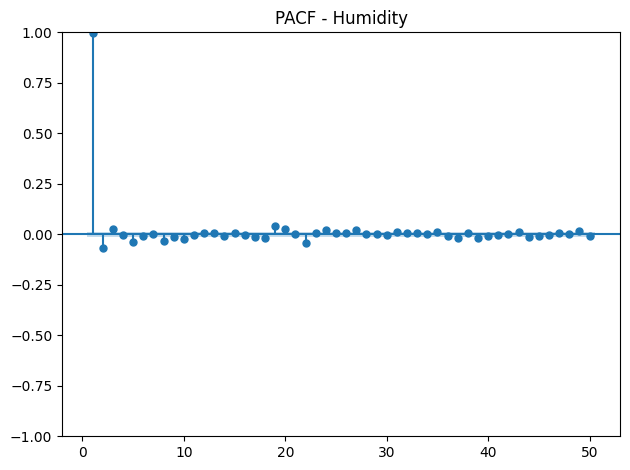

In [2]:

# 1. library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf

df = pd.read_csv("smart_sensors_smoothed.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['humid'] = pd.to_numeric(df['humid'], errors='coerce')
df = df.sort_values("result_time")

max_date = df['result_time'].max()
start_date = max_date - pd.Timedelta(days=15)
df_last15 = df[df['result_time'] >= start_date]

# 2. data visualization

# temperature plot
plt.figure(figsize=(10, 4))
plt.plot(df_last15['result_time'], df_last15['temp'], label='Temperature', color='red')
plt.title('Temperature over Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

# humidity plot
plt.figure(figsize=(10, 4))
plt.plot(df_last15['result_time'], df_last15['humid'], label='Humidity', color='blue')
plt.title('Humidity over Time')
plt.xlabel('Time')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. stationarity evaluation
df_last15 = df_last15.set_index('result_time')

series_t = df_last15['temp']

result = adfuller(series_t)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


series_h = df_last15['humid']

result = adfuller(series_h)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# 4. PACF plotting
# PACF plot - temperatura
plt.figure(figsize=(8, 4))
plot_pacf(series_t.dropna(), lags=50, method='ywm', zero=False)
plt.title('PACF - Temperature')
plt.tight_layout()
plt.show()

# PACF plot - umidità
plt.figure(figsize=(8, 4))
plot_pacf(series_h.dropna(), lags=50, method='ywm', zero=False)
plt.title('PACF - Humidity')
plt.tight_layout()
plt.show()

### Some consideration:
- _The time series are stationary._
- _From PACF we can't notice interesting patterns._
- _In temperature time series ther may be a seasonality._
- _In next code cell we evaluate this possibility._


## Seasonality Temperature Time Series Analisys

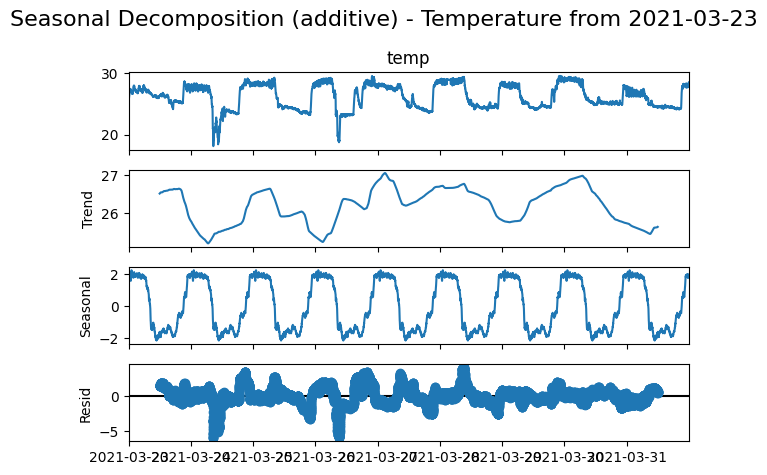

Shapiro-Wilk statistic: 0.9763
p-value: 1.023e-11
H0 rejected. No gaussian distribution


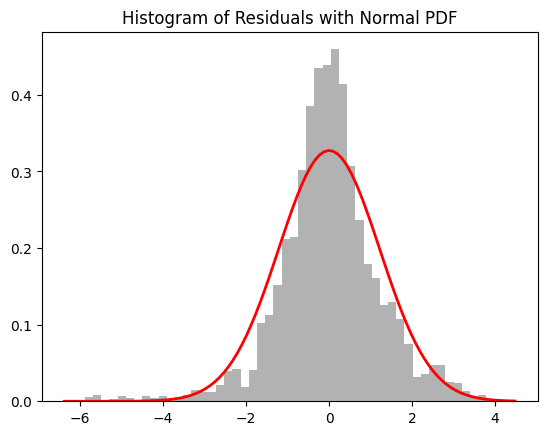

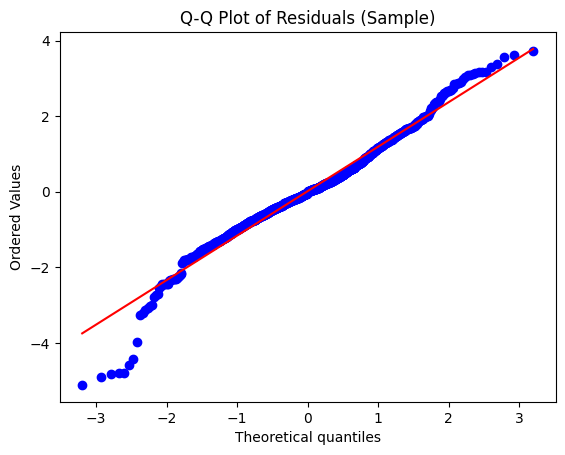

Root Mean Squared Error (RMSE): 1.2190


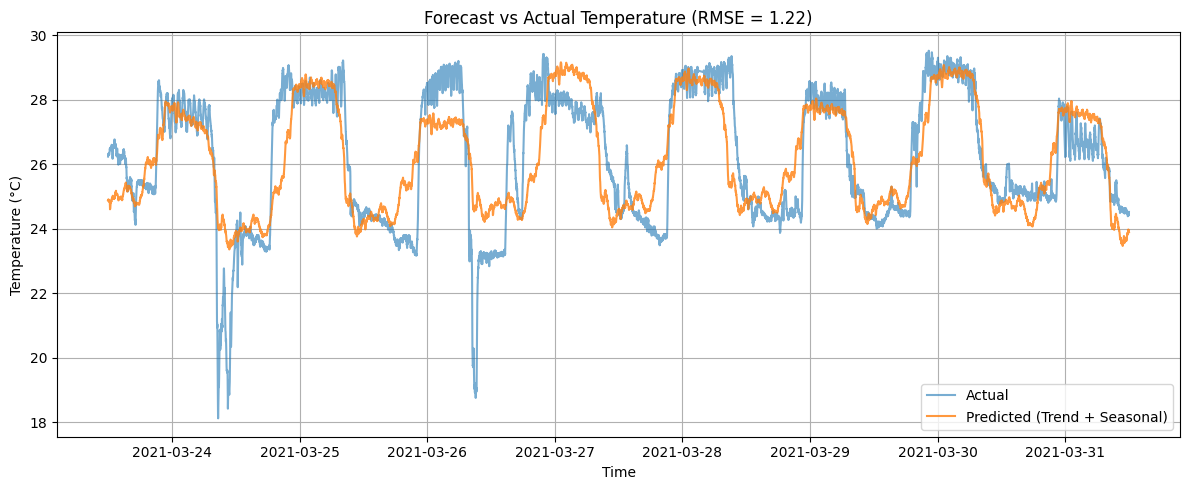

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import shapiro
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error
from math import sqrt

# 1. Loading and preprocessing
df = pd.read_csv("smart_sensors_smoothed.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df = df.sort_values("result_time")
df_filtered = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df_filtered = df_filtered.set_index('result_time')
series_temp = df_filtered['temp'].interpolate()

# 2. Decomposition
model_type = 'additive'
result = seasonal_decompose(series_temp, model=model_type, period=1440)
result.plot()
plt.suptitle(f'Seasonal Decomposition ({model_type}) - Temperature from 2021-03-23', fontsize=16)
plt.tight_layout()
plt.show()

resid = result.resid.dropna()
sample_size = min(len(resid), 1000)
resid_sample = resid.sample(sample_size, random_state=42)

# 3. Residual analysis

# Shapiro-Wilk
stat, p = shapiro(resid_sample)

print(f"Shapiro-Wilk statistic: {stat:.4f}")
print(f"p-value: {p:.4g}")

if p > 0.05:
    print("H0 not rejected. Gaussian distribution")
else:
    print("H0 rejected. No gaussian distribution")

# Histogram
plt.hist(resid, bins=50, density=True, alpha=0.6, color='gray')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_pdf = stats.norm.pdf(x, resid.mean(), resid.std())
plt.plot(x, p_pdf, 'r', linewidth=2)
plt.title("Histogram of Residuals with Normal PDF")
plt.show()

# Q-Q plot
stats.probplot(resid_sample, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Sample)")
plt.show()

# Plotting series without residuid
df = pd.read_csv("smart_sensors_smoothed.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df = df.sort_values("result_time")

df_filtered = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df_filtered = df_filtered.set_index('result_time')
series = df_filtered['temp'].interpolate()

result = seasonal_decompose(series, model='additive', period=1440)

predicted = result.trend + result.seasonal

aligned_actual = series[result.trend.dropna().index]
aligned_predicted = predicted.dropna()

rmse = sqrt(mean_squared_error(aligned_actual, aligned_predicted))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(aligned_actual.index, aligned_actual, label='Actual', alpha=0.6)
plt.plot(aligned_predicted.index, aligned_predicted, label='Predicted (Trend + Seasonal)', alpha=0.8)
plt.title(f'Forecast vs Actual Temperature (RMSE = {rmse:.2f})')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




### Note:
_With multiplicative seasonality we have more or less same result. So it's not introduced in the notebook but it's been take in consideration._

## Humidity Time Series Training & Evaluaton 

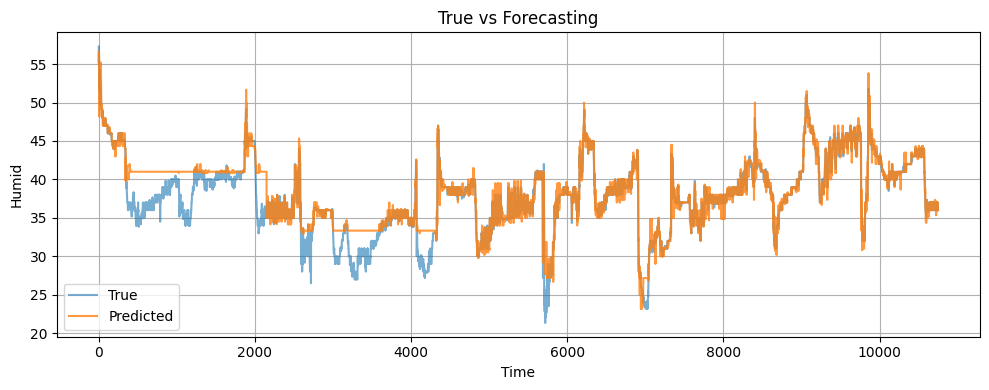

RMSE(CV): 1.93
final model trained and tested.


In [4]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from math import sqrt
import joblib

# 1. Dataset Loading
df = pd.read_csv("smart_sensors_smoothed.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df_filtered = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df_filtered = df_filtered.set_index('result_time')
series = df_filtered[['humid']].interpolate()

# 2. Lag Table
def create_lagged_features(series, n_lags):
    X, y = [], []
    values = series['humid'].values
    for i in range(n_lags, len(values)):
        X.append(values[i - n_lags:i])
        y.append(values[i])
    return np.array(X), np.array(y)

n_lags = 60
X, y = create_lagged_features(series, n_lags)

# 4. TimeSeriesSplit Cross Validation
tscv = TimeSeriesSplit(n_splits=5)
preds = []
reals = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = model = DecisionTreeRegressor(
        max_depth=20,
        max_leaf_nodes=5000
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    preds.extend(y_pred)
    reals.extend(y_test)

# 5. Plot & final RMSE
plt.figure(figsize=(10, 4))
plt.plot(reals, label="True", alpha=0.6)
plt.plot(preds, label="Predicted", alpha=0.8)
plt.title("True vs Forecasting")
plt.xlabel("Time")
plt.ylabel("Humid")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rmse_total = sqrt(np.mean((np.array(preds) - np.array(reals)) ** 2))
print(f"RMSE(CV): {rmse_total:.2f}")

# 6. Final Training
final_model =  DecisionTreeRegressor(
    max_depth=20,
    max_leaf_nodes=5000
    )
final_model.fit(X, y)

# 7. Model Saving
joblib.dump(final_model, "final_humid_model.joblib")
print("final model trained and tested.")

## Temperature Time Series Training & Evaluaton 

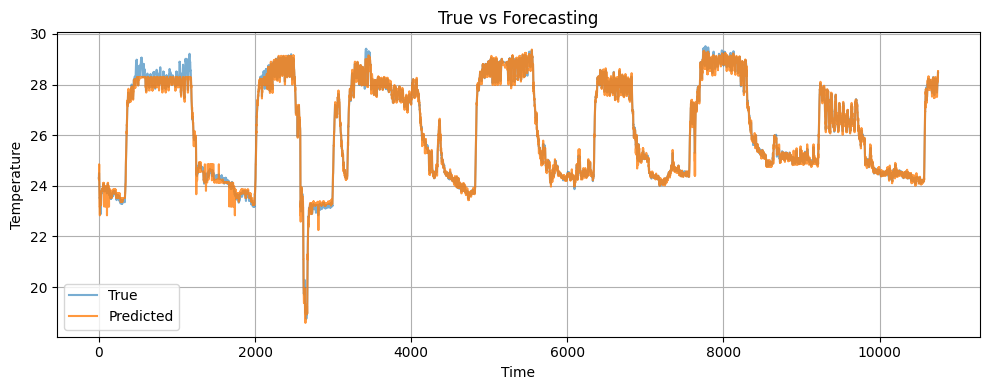

RMSE(CV): 0.14
final model trained and tested.


In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from math import sqrt
import joblib

# 1. Dataset Loading
df = pd.read_csv("smart_sensors_smoothed.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df_filtered = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df_filtered = df_filtered.set_index('result_time')
series = df_filtered[['temp']].interpolate()

# 2. Lag Table
def create_lagged_features(series, n_lags):
    X, y = [], []
    values = series['temp'].values
    for i in range(n_lags, len(values)):
        X.append(values[i - n_lags:i])
        y.append(values[i])
    return np.array(X), np.array(y)

n_lags = 60
X, y = create_lagged_features(series, n_lags)

# 4. TimeSeriesSplit Cross Validation
tscv = TimeSeriesSplit(n_splits=5)
preds = []
reals = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = DecisionTreeRegressor(
        max_depth=20,
        max_leaf_nodes=5000
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    preds.extend(y_pred)
    reals.extend(y_test)

# 5. Plot & final RMSE
plt.figure(figsize=(10, 4))
plt.plot(reals, label="True", alpha=0.6)
plt.plot(preds, label="Predicted", alpha=0.8)
plt.title("True vs Forecasting")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rmse_total = sqrt(np.mean((np.array(preds) - np.array(reals)) ** 2))
print(f"RMSE(CV): {rmse_total:.2f}")

# 6. Final Training
final_model = DecisionTreeRegressor(
    max_depth=20,
    max_leaf_nodes=5000
    )
final_model.fit(X, y)

# 7. Model Saving
joblib.dump(final_model, "final_temp_model.joblib")
print("final model trained and tested.")




## Emlearn Conversion

In [6]:
import emlearn
import joblib

# TEMPERATURE
model1 = joblib.load("final_temp_model.joblib")
cmodel1 = emlearn.convert(model1, method='inline')
path1 = 'temperature_forecast_converted.h'
c_name1 = 'temperature_forecast'
cmodel1.save(file=path1, name=c_name1)
print('Wrote model to', path1)

# HUMIDITY
model2 = joblib.load("final_humid_model.joblib")
cmodel2 = emlearn.convert(model2, method='inline')
path2 = 'humidity_forecast_converted.h'
c_name2 = 'humidity_forecast'
cmodel2.save(file=path2, name=c_name2)
print('Wrote model to', path2)

Wrote model to temperature_forecast_converted.h
Wrote model to humidity_forecast_converted.h


In [7]:
print("Numero totale di nodi:", model1.tree_.node_count)
print("Profondità massima dell’albero:", model1.tree_.max_depth)

# Calcolo del numero di foglie (nodi senza figli)
children_left = model1.tree_.children_left
children_right = model1.tree_.children_right
n_leaves = sum((children_left == -1) & (children_right == -1))
print("Numero di foglie:", n_leaves)



Numero totale di nodi: 9999
Profondità massima dell’albero: 20
Numero di foglie: 5000


In [10]:
mean_humidity = df_last15['humid'].mean()
std_humidity = df_last15['humid'].std()
mean_temperature = df_last15['temp'].mean()
std_temperature = df_last15['temp'].std()

print("Mean Humidity:", mean_humidity)
print("Standard Deviation Humidity:", std_humidity)
print("Mean Temperature:", mean_temperature)
print("Standard Deviation Temperature:", std_temperature)


Mean Humidity: 41.08854743896558
Standard Deviation Humidity: 5.829130107063543
Mean Temperature: 26.34405568073295
Standard Deviation Temperature: 1.8465693913564167
